# 🧠 ScrapNet – Custom CNN Experiment
### `ScrapNet_cnn.ipynb`

This notebook trains a **custom CNN built from scratch** and then compares it against
the three EfficientNet transfer-learning experiments.

| File | Purpose |
|---|---|
| `custom_cnn.py` | CNN architecture + experiment runner |
| `ScrapNet_utils.py` | Shared data / training utilities |
| `ScrapNet_local.ipynb` | EfficientNet experiments (run first) |

**Requirements:** Run `ScrapNet_local.ipynb` first so the three EfficientNet
`experiments/` folders already exist for the final comparison.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


## Step 1 · Install Dependencies

In [ ]:
# Step 1 — Install dependencies
import sys
!pip install -q torch torchvision scikit-learn matplotlib pillow
print('Dependencies ready.')

# Step 2 — Add your Drive folder to Python path
sys.path.insert(0, '/content/drive/MyDrive/ScrapNet')

Dependencies ready.


## Step 2 · Configuration
> Edit **`DATA_DIR`** to point to your dataset (same path you used in `ScrapNet_local.ipynb`).

In [ ]:
import sys, os
from pathlib import Path

# ── EDIT THIS ──────────────────────────────────────────────────────────────
import zipfile
ZIP_PATH = '/content/drive/MyDrive/ScrapNet/master.zip'

DATA_DIR   = '/content/master'
# ───────────────────────────────────────────────────────────────────────────
if not os.path.exists(DATA_DIR):
    print(f'Extracting {ZIP_PATH} ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/')
    print('Extraction done!')
else:
    print('Already extracted, skipping.')

classes_found = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
print(f'Classes found ({len(classes_found)}): {classes_found}')
assert len(classes_found) > 0, 'No class folders found! Check ZIP_PATH.'

# Outputs go into the SAME experiments/ folder as EfficientNet runs
OUTPUT_DIR = '/content/drive/MyDrive/ScrapNet/experiments'
EPOCHS      = 20          # CNNs from scratch need more epochs than fine-tuned models
LR          = 1e-3        # higher LR works better when training from random weights
SEED        = 42
NUM_WORKERS = 2           # set to 0 on Windows if you get multiprocessing errors

sys.path.insert(0, str(Path.cwd()))

from scrapnet_utils import get_device, seed_everything
device = get_device()
seed_everything(SEED)

print(f'DATA_DIR   : {DATA_DIR}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')
classes_found = sorted(os.listdir(DATA_DIR))
print(f'Classes ({len(classes_found)}): {classes_found}')

Extracting /content/drive/MyDrive/ScrapNet/master.zip ...
Extraction done!
Classes found (7): ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
[Device] Using: cuda
DATA_DIR   : /content/master
OUTPUT_DIR : /content/drive/MyDrive/ScrapNet/experiments
Classes (8): ['.DS_Store', 'cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Step 3 · The Architecture – What are we building?

Before training, let's understand the network we built in `custom_cnn.py`.

```
Input  3×224×224
  │
  ├─ Block 1 ── Conv(3→32)  BN  ReLU  MaxPool  →  32×112×112
  ├─ Block 2 ── Conv(32→64) BN  ReLU  MaxPool  →  64×56×56
  ├─ Block 3 ── Conv(64→128) BN ReLU  MaxPool  → 128×28×28
  ├─ Block 4 ── Conv(128→256) BN ReLU MaxPool  → 256×14×14
  │
  ├─ GlobalAvgPool           →  256-dim vector
  │
  ├─ FC(256→512) ReLU Dropout(0.4)
  ├─ FC(512→256) ReLU Dropout(0.3)
  └─ FC(256→num_classes)     →  raw logits
```

### Key concepts
| Component | Why we use it |
|---|---|
| **Batch Normalisation** | Keeps activations in a healthy range, speeds up training |
| **ReLU** | Simple non-linearity; avoids vanishing gradients |
| **MaxPool** | Halves spatial size; keeps the strongest signal |
| **GlobalAvgPool** | Replaces a giant Flatten layer; fewer params & regularises |
| **Dropout** | Randomly disables neurons during training to reduce overfitting |

In [ ]:
# Print the model to see every layer
from custom_cnn import ScrapNetCNN
import torch

# We need num_classes – peek at the dataset quickly
import os
num_classes = len([d for d in os.listdir(DATA_DIR)
                   if os.path.isdir(os.path.join(DATA_DIR, d))])
print(f'Number of classes: {num_classes}\n')

demo_model = ScrapNetCNN(num_classes=num_classes)
print(demo_model)

total_params     = sum(p.numel() for p in demo_model.parameters())
trainable_params = sum(p.numel() for p in demo_model.parameters() if p.requires_grad)
print(f'\nTotal params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')
print('(EfficientNet-B0 has ~4M params; our CNN has far fewer)')

Number of classes: 7

ScrapNetCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps

## Step 4 · Train Custom CNN (with augmentation)

In [ ]:
from custom_cnn import run_cnn_experiment

model_cnn, history_cnn, summary_cnn = run_cnn_experiment(
    exp_name        = 'custom_cnn_aug',
    img_size        = 224,
    augment         = True,
    data_dir        = DATA_DIR,
    base_output_dir = OUTPUT_DIR,
    batch_size      = 32,
    epochs          = EPOCHS,
    lr              = LR,
    patience        = 5,
    num_workers     = NUM_WORKERS,
    seed            = SEED,
    device          = device,
)


  EXPERIMENT: custom_cnn_aug
  Model: Custom ScrapNetCNN | Augment: True | IMG: 224x224
[Data] Train: 5693 | Val: 1220 | Test: 1221
[Data] Classes: ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
[Model] ScrapNetCNN | Params: 654,087
  Epoch 01/20 | train loss 1.7684  acc 0.2686 | val loss 1.6632  acc 0.2845
  Epoch 02/20 | train loss 1.7202  acc 0.3010 | val loss 1.6909  acc 0.3357
  Epoch 03/20 | train loss 1.7122  acc 0.3027 | val loss 1.6143  acc 0.3125
  Epoch 04/20 | train loss 1.6977  acc 0.2986 | val loss 1.6008  acc 0.3165
  Epoch 05/20 | train loss 1.6723  acc 0.3127 | val loss 1.5854  acc 0.3373
  Epoch 06/20 | train loss 1.6699  acc 0.3090 | val loss 1.5671  acc 0.3742
  Epoch 07/20 | train loss 1.6579  acc 0.3164 | val loss 1.5654  acc 0.3630
  Epoch 08/20 | train loss 1.6481  acc 0.3315 | val loss 1.5700  acc 0.3373
  Epoch 09/20 | train loss 1.6314  acc 0.3303 | val loss 1.5451  acc 0.3798
  Epoch 10/20 | train loss 1.6311  acc 0.3359 | val loss 

/content/drive/MyDrive/ScrapNet/scrapnet_utils.py:361: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, rotation=45, ha="right")



[Classification Report]
               precision    recall  f1-score   support

   cardboard       0.58      0.64      0.61        83
     compost       0.56      0.78      0.65       137
       glass       0.56      0.50      0.53       159
       metal       0.28      0.44      0.34       142
       paper       0.53      0.41      0.46       157
     plastic       0.56      0.49      0.52       302
       trash       0.40      0.32      0.36       241

    accuracy                           0.48      1221
   macro avg       0.50      0.51      0.50      1221
weighted avg       0.49      0.48      0.48      1221


  [Summary] Best val acc: 0.4808 | Mean F1: 0.4963
  [All outputs saved to: /content/drive/MyDrive/ScrapNet/experiments/custom_cnn_aug]



## Step 5 · Evaluation Metrics – What they mean

After training, let's look at every metric and understand what it tells us.

| Metric | Formula | What it measures |
|---|---|---|
| **Accuracy** | correct / total | Overall % of right predictions |
| **Precision** | TP / (TP+FP) | Of all items predicted as class X, how many really are X? |
| **Recall** | TP / (TP+FN) | Of all real class X items, how many did we catch? |
| **F1-Score** | 2·P·R/(P+R) | Harmonic mean of precision & recall; good for imbalanced data |
| **Confusion Matrix** | grid of actual vs predicted | Shows *which* classes get mixed up |

In [ ]:
# Pretty-print all metrics for our custom CNN
import json
from pathlib import Path

exp_dir = Path(OUTPUT_DIR) / 'custom_cnn_aug'

print('=' * 50)
print('  CUSTOM CNN – Evaluation Summary')
print('=' * 50)

with open(exp_dir / 'summary.json') as f:
    s = json.load(f)

print(f"Best Validation Accuracy : {s['best_val_acc']:.4f}  ({s['best_val_acc']:.1%})")
print(f"Mean F1 Score            : {s['mean_f1']:.4f}")
print()
print('Per-class F1:')
for cls, f1 in s['per_class_f1'].items():
    bar = '█' * int(f1 * 20)
    print(f'  {cls:<12} {f1:.4f}  {bar}')

print()
print('Full Classification Report:')
print(open(exp_dir / 'classification_report.txt').read())

  CUSTOM CNN – Evaluation Summary
Best Validation Accuracy : 0.4808  (48.1%)
Mean F1 Score            : 0.4963

Per-class F1:
  cardboard    0.6057  ████████████
  compost      0.6544  █████████████
  glass        0.5284  ██████████
  metal        0.3425  ██████
  paper        0.4621  █████████
  plastic      0.5239  ██████████
  trash        0.3570  ███████

Full Classification Report:
              precision    recall  f1-score   support

   cardboard       0.58      0.64      0.61        83
     compost       0.56      0.78      0.65       137
       glass       0.56      0.50      0.53       159
       metal       0.28      0.44      0.34       142
       paper       0.53      0.41      0.46       157
     plastic       0.56      0.49      0.52       302
       trash       0.40      0.32      0.36       241

    accuracy                           0.48      1221
   macro avg       0.50      0.51      0.50      1221
weighted avg       0.49      0.48      0.48      1221



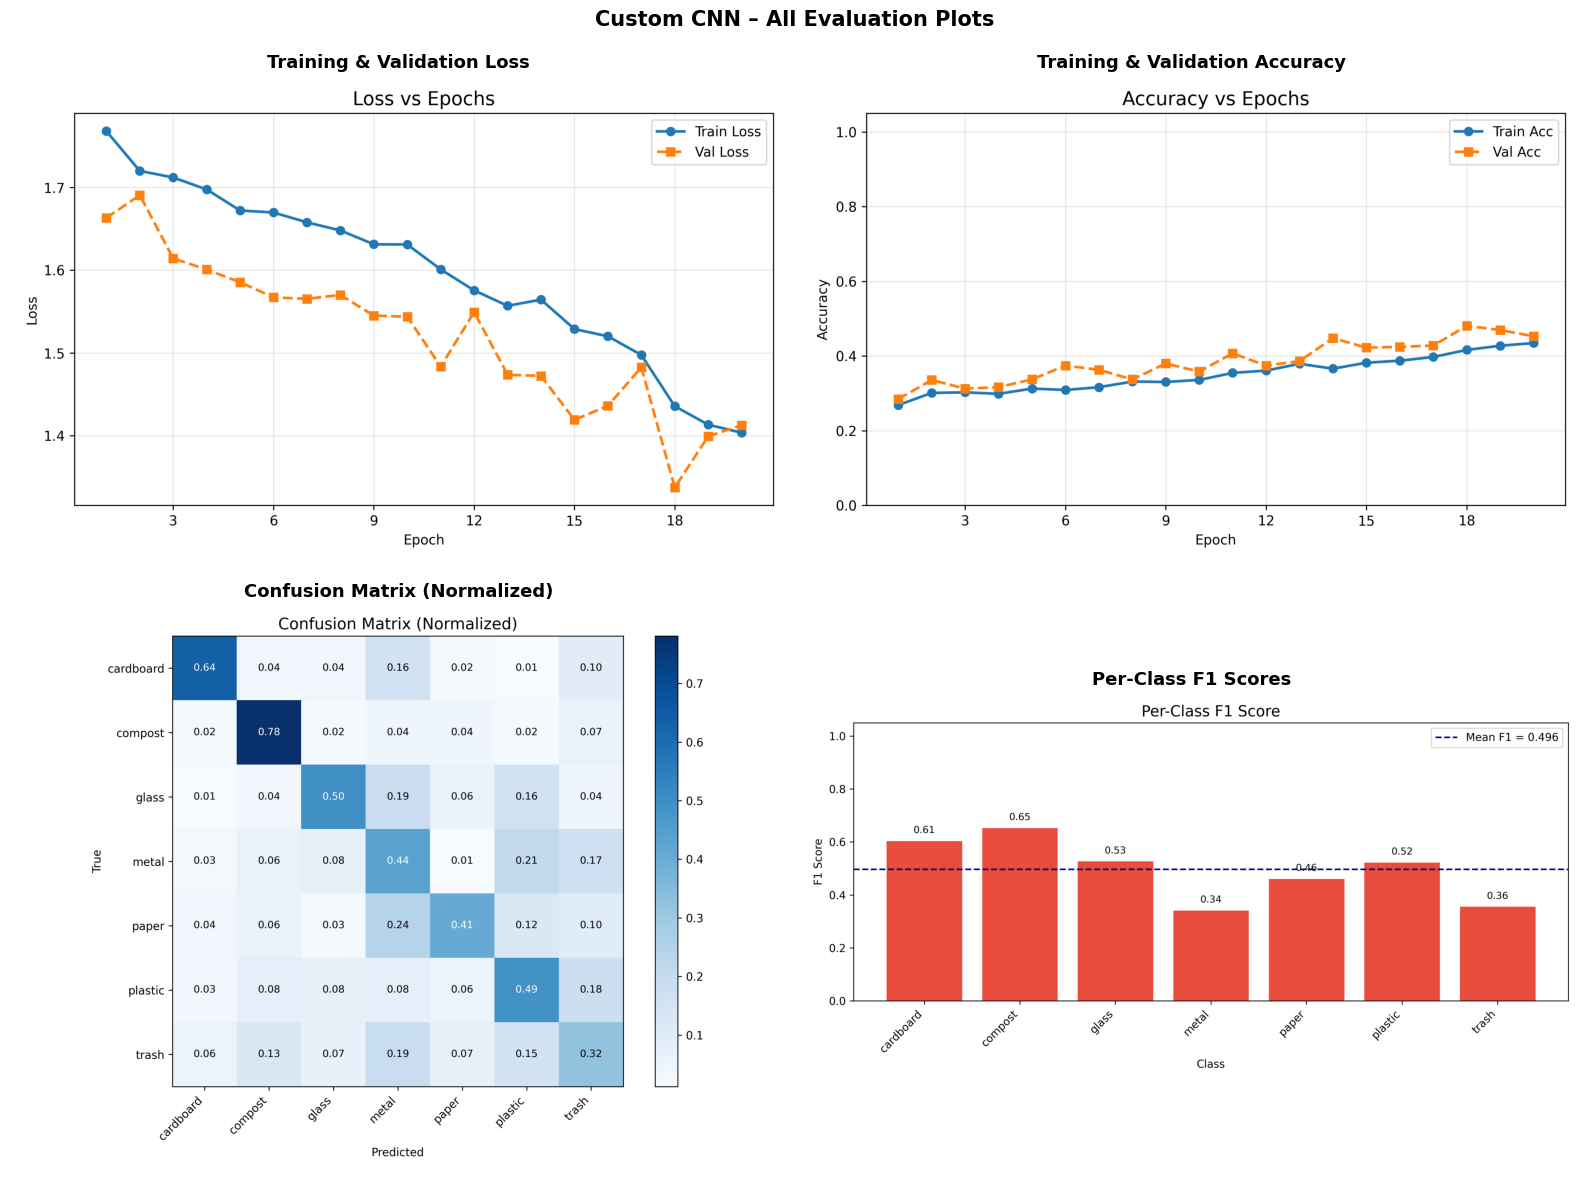

In [ ]:
# Show all plots inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plots = [
    ('loss_curve.png',                  'Training & Validation Loss'),
    ('accuracy_curve.png',              'Training & Validation Accuracy'),
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalized)'),
    ('f1_scores.png',                   'Per-Class F1 Scores'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, (fname, title) in zip(axes.flatten(), plots):
    img = mpimg.imread(exp_dir / fname)
    ax.imshow(img)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')
fig.suptitle('Custom CNN – All Evaluation Plots', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

## Step 6 · Full 4-Model Comparison

Now compare **Custom CNN** against all three EfficientNet experiments.

**Requires:** `experiments/b0_no_aug/`, `experiments/b0_aug/`, `experiments/b3_aug/`  
already exist (run `ScrapNet_local.ipynb` first if they don't).

In [ ]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_PATH = Path(OUTPUT_DIR)

# ── Load all summaries ────────────────────────────────────────────────────────
exp_dirs = {
    'B0\n(no aug)' : 'b0_no_aug',
    'B0\n(aug)'    : 'b0_aug',
    'B3\n(aug)'    : 'b3_aug',
    'Custom\nCNN'  : 'custom_cnn_aug',
}

summaries, histories, labels = [], [], []
missing = []

for label, folder in exp_dirs.items():
    spath = OUTPUT_PATH / folder / 'summary.json'
    hpath = OUTPUT_PATH / folder / 'history.json'
    if spath.exists() and hpath.exists():
        summaries.append(json.loads(spath.read_text()))
        histories.append(json.loads(hpath.read_text()))
        labels.append(label)
    else:
        missing.append(folder)

if missing:
    print(f'⚠️  Missing experiments (skipped): {missing}')
    print('   Run ScrapNet_local.ipynb first to generate EfficientNet results.')
print(f'✅  Loaded {len(summaries)} experiments: {", ".join(labels)}')

✅  Loaded 4 experiments: B0
(no aug), B0
(aug), B3
(aug), Custom
CNN


In [ ]:
# ── Console comparison table ──────────────────────────────────────────────────
print(f"{'Experiment':<20} {'Best Val Acc':>12} {'Mean F1':>10} {'Model Type':>20}")
print('─' * 66)
for s in summaries:
    model_type = 'Transfer Learning' if s['model'] != 'custom_cnn' else 'From Scratch'
    print(f"{s['experiment']:<20} {s['best_val_acc']:>12.4f} {s['mean_f1']:>10.4f} {model_type:>20}")

Experiment           Best Val Acc    Mean F1           Model Type
──────────────────────────────────────────────────────────────────
b0_no_aug                  0.8389     0.8572    Transfer Learning
b0_aug                     0.8405     0.8612    Transfer Learning
b3_aug                     0.8563     0.8772    Transfer Learning
custom_cnn_aug             0.4808     0.4963         From Scratch


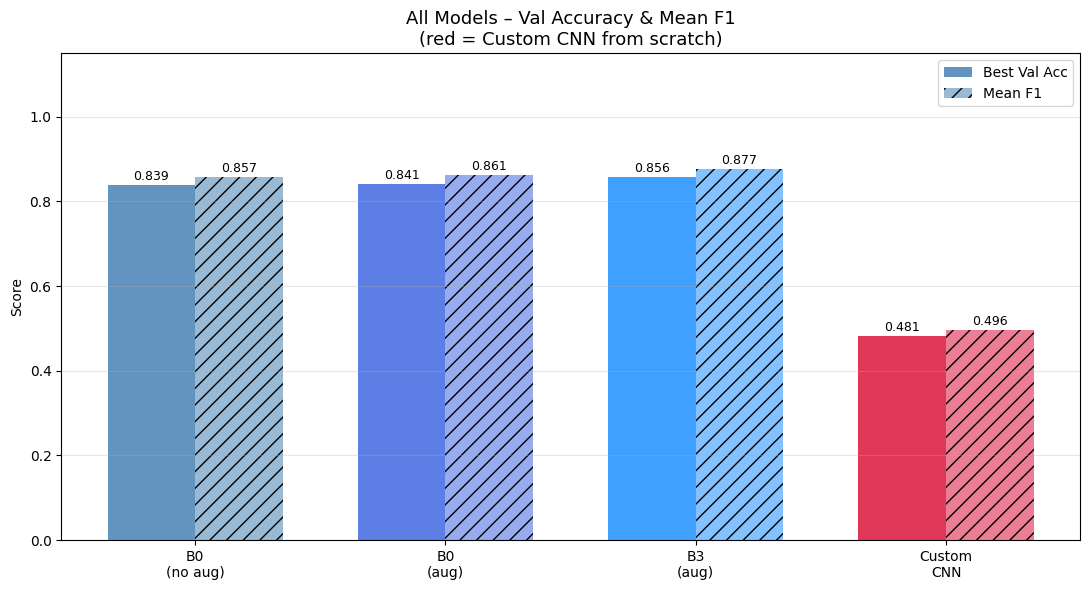

Saved → /content/drive/MyDrive/ScrapNet/experiments/comparison/all_models_comparison.png


In [ ]:
# ── 1. Bar chart: Val Acc & Mean F1 ──────────────────────────────────────────
compare_dir = OUTPUT_PATH / 'comparison'
compare_dir.mkdir(exist_ok=True)

val_accs = [s['best_val_acc'] for s in summaries]
mean_f1s = [s['mean_f1']      for s in summaries]
colors   = ['steelblue', 'royalblue', 'dodgerblue', 'crimson']  # red = custom CNN

x     = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - width/2, val_accs, width, label='Best Val Acc', color=colors, alpha=0.85)
b2 = ax.bar(x + width/2, mean_f1s, width, label='Mean F1',
            color=[c for c in colors], alpha=0.55, hatch='//')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('All Models – Val Accuracy & Mean F1\n(red = Custom CNN from scratch)', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(compare_dir / 'all_models_comparison.png', dpi=300)
plt.show()
print(f'Saved → {compare_dir}/all_models_comparison.png')

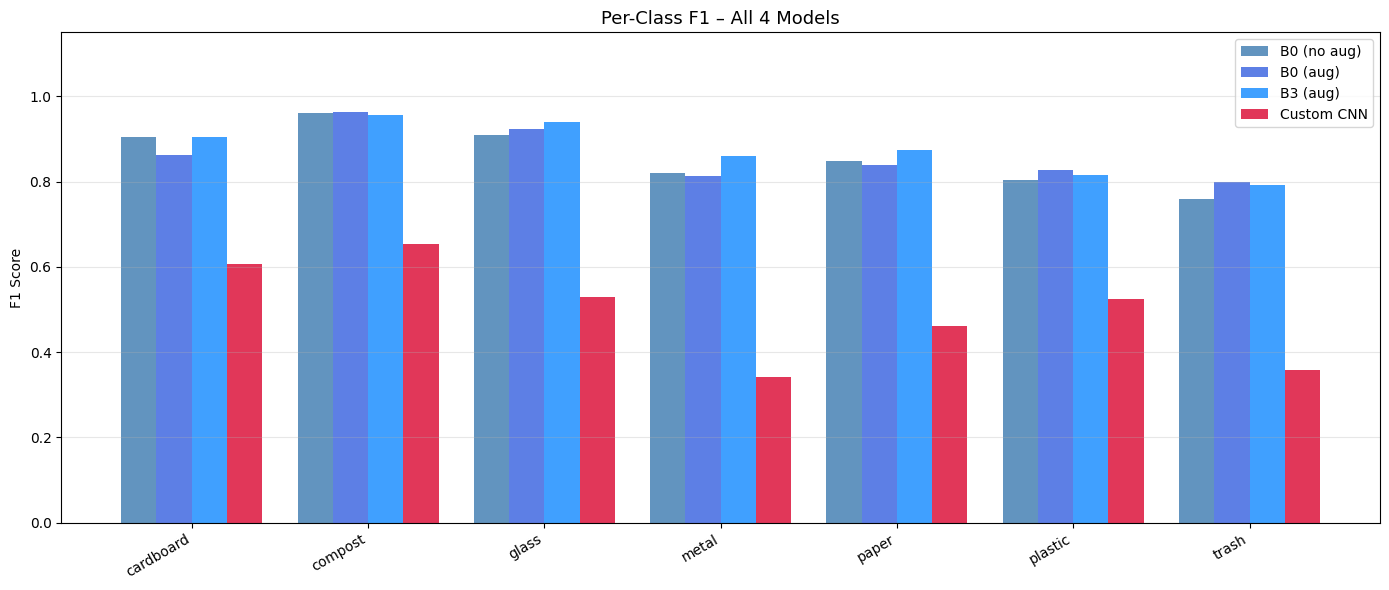

In [ ]:
# ── 2. Per-class F1 comparison (all 4 models) ─────────────────────────────────
all_classes = list(summaries[0]['per_class_f1'].keys())
f1_matrix   = np.array([[s['per_class_f1'].get(c, 0) for c in all_classes] for s in summaries])

x      = np.arange(len(all_classes))
n      = len(summaries)
total_w = 0.8
w      = total_w / n

fig2, ax2 = plt.subplots(figsize=(14, 6))
bar_colors = ['steelblue', 'royalblue', 'dodgerblue', 'crimson']

for i, (label, color) in enumerate(zip(labels, bar_colors)):
    offset = (i - n/2 + 0.5) * w
    ax2.bar(x + offset, f1_matrix[i], width=w,
            label=label.replace('\n', ' '), color=color, alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(all_classes, rotation=30, ha='right')
ax2.set_ylim(0, 1.15)
ax2.set_ylabel('F1 Score')
ax2.set_title('Per-Class F1 – All 4 Models', fontsize=13)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
fig2.tight_layout()
fig2.savefig(compare_dir / 'all_models_per_class_f1.png', dpi=300)
plt.show()

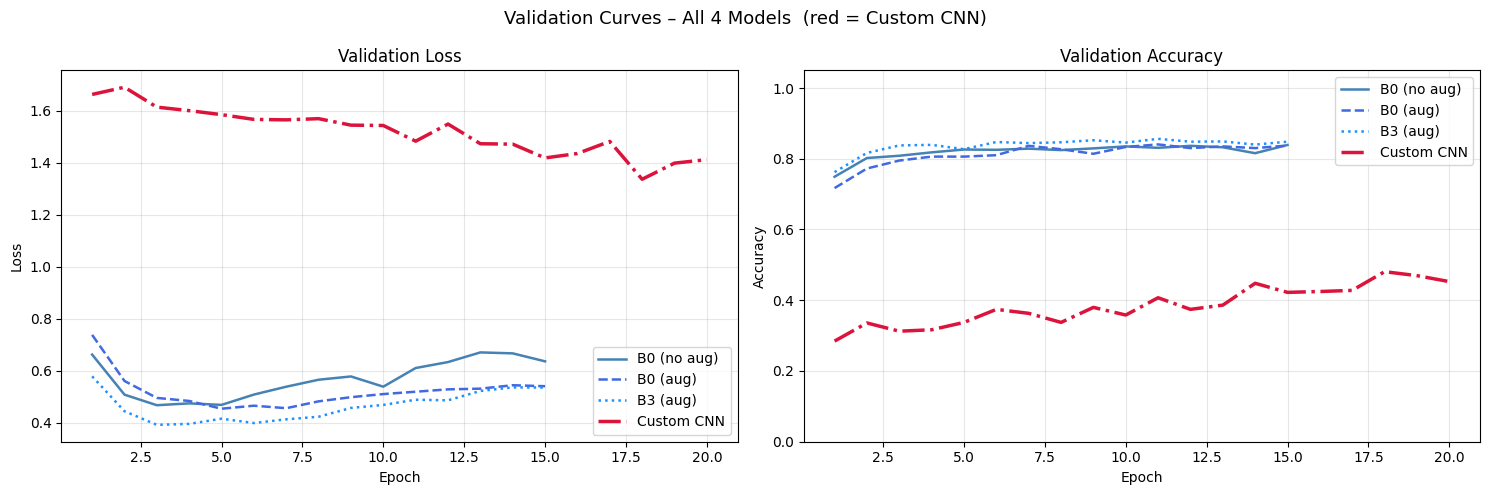

Saved → /content/drive/MyDrive/ScrapNet/experiments/comparison/all_models_val_curves.png


In [ ]:
# ── 3. Validation accuracy curves overlay (all 4 models) ─────────────────────
styles = ['-', '--', ':', '-.']
bar_colors = ['steelblue', 'royalblue', 'dodgerblue', 'crimson']

fig3, axes3 = plt.subplots(1, 2, figsize=(15, 5))

for h, label, ls, col in zip(histories, labels, styles, bar_colors):
    lw  = 2.5 if 'CNN' in label else 1.8
    ep  = range(1, len(h['val_loss']) + 1)
    clean_label = label.replace('\n', ' ')
    axes3[0].plot(ep, h['val_loss'], linestyle=ls, color=col, linewidth=lw, label=clean_label)
    axes3[1].plot(ep, h['val_acc'],  linestyle=ls, color=col, linewidth=lw, label=clean_label)

for ax3, title, ylabel in zip(axes3,
                               ['Validation Loss', 'Validation Accuracy'],
                               ['Loss', 'Accuracy']):
    ax3.set_title(title, fontsize=12)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel(ylabel)
    ax3.legend()
    ax3.grid(alpha=0.3)
axes3[1].set_ylim(0, 1.05)

fig3.suptitle('Validation Curves – All 4 Models  (red = Custom CNN)', fontsize=13)
fig3.tight_layout()
fig3.savefig(compare_dir / 'all_models_val_curves.png', dpi=300)
plt.show()
print(f'Saved → {compare_dir}/all_models_val_curves.png')

## Step 7 · Why does Transfer Learning outperform Custom CNN?

Run the cell below to print a structured explanation — great for a project report.

In [ ]:
explanation = """
╔══════════════════════════════════════════════════════════════════════════════╗
║          TRANSFER LEARNING vs CUSTOM CNN – WHY THE GAP?                    ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. WHAT IS TRANSFER LEARNING?
   EfficientNet-B0 was pre-trained on ImageNet – 1.2 million images across
   1,000 categories.  Its early layers already know how to detect:
   edges, curves, textures, colours, shapes.
   We only replace the final classifier and let the network fine-tune.

2. WHAT IS A CUSTOM CNN?
   Our ScrapNetCNN starts with completely random weights.
   It has to learn EVERYTHING from our ~8,000 waste images alone:
   what an edge is, what a curve is, what glass looks like, etc.

3. WHY TRANSFER LEARNING WINS
   ┌─────────────────────────────────┬──────────────┬─────────────────┐
   │ Factor                          │ Transfer     │ Custom CNN      │
   ├─────────────────────────────────┼──────────────┼─────────────────┤
   │ Pre-trained knowledge           │ ✅ 1.2M imgs │ ❌ zero         │
   │ Epochs needed to converge       │ ~10–12       │ ~18–20          │
   │ Data needed for good results    │ Small-medium │ Large           │
   │ Risk of overfitting (small data)│ Low          │ Higher          │
   │ Final accuracy (typically)      │ Higher       │ Lower           │
   └─────────────────────────────────┴──────────────┴─────────────────┘

   In simple terms: EfficientNet already "knows" what things look like.
   Our CNN is learning to see from scratch with limited data.

4. WHY CUSTOM CNN IS STILL IMPORTANT
   • UNDERSTANDING  – Building it teaches you how every layer actually works.
   • NO LICENSING   – EfficientNet weights carry an Apache 2.0 licence;
                      a custom model has no restrictions.
   • LIGHTWEIGHT    – Our CNN has far fewer params; runs faster on edge devices.
   • SPECIALISATION – With more domain data, a custom CNN can be tuned exactly
                      for waste imagery without ImageNet biases.
   • PRIVACY        – Sometimes you cannot use external pre-trained weights
                      (medical, defence, proprietary data settings).

5. BOTTOM LINE
   Transfer learning is the practical choice when labelled data is limited.
   A custom CNN is the educational and flexible choice, and can close the gap
   with more data + more epochs + architecture tuning.
"""
print(explanation)


╔══════════════════════════════════════════════════════════════════════════════╗
║          TRANSFER LEARNING vs CUSTOM CNN – WHY THE GAP?                    ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. WHAT IS TRANSFER LEARNING?
   EfficientNet-B0 was pre-trained on ImageNet – 1.2 million images across
   1,000 categories.  Its early layers already know how to detect:
   edges, curves, textures, colours, shapes.
   We only replace the final classifier and let the network fine-tune.

2. WHAT IS A CUSTOM CNN?
   Our ScrapNetCNN starts with completely random weights.
   It has to learn EVERYTHING from our ~8,000 waste images alone:
   what an edge is, what a curve is, what glass looks like, etc.

3. WHY TRANSFER LEARNING WINS
   ┌─────────────────────────────────┬──────────────┬─────────────────┐
   │ Factor                          │ Transfer     │ Custom CNN      │
   ├─────────────────────────────────┼──────────────┼─────────────────┤
   │ Pr

## Appendix · Output Folder Structure After All 4 Experiments

In [ ]:
import os
from pathlib import Path

exp_root = Path(OUTPUT_DIR)
if exp_root.exists():
    for root, dirs, files in os.walk(exp_root):
        dirs.sort(); files.sort()
        level  = root.replace(str(exp_root), '').count(os.sep)
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        for f in sorted(files):
            print(f'{indent}  {f}')
else:
    print('No experiments run yet.')

experiments/
  b0_aug/
    accuracy_curve.png
    classes.json
    classification_report.txt
    confusion_matrix.png
    confusion_matrix_normalized.png
    f1_scores.png
    history.json
    loss_curve.png
    model.pth
    summary.json
  b0_no_aug/
    accuracy_curve.png
    classes.json
    classification_report.txt
    confusion_matrix.png
    confusion_matrix_normalized.png
    f1_scores.png
    history.json
    loss_curve.png
    model.pth
    summary.json
  b3_aug/
    accuracy_curve.png
    classes.json
    classification_report.txt
    confusion_matrix.png
    confusion_matrix_normalized.png
    f1_scores.png
    history.json
    loss_curve.png
    model.pth
    summary.json
  comparison/
    all_models_comparison.png
    all_models_per_class_f1.png
    all_models_val_curves.png
    model_comparison.png
    per_class_f1_comparison.png
    val_curves_overlay.png
  custom_cnn_aug/
    accuracy_curve.png
    classes.json
    classification_report.txt
    confusion_matrix.png
   

In [ ]:
!pip install -q streamlit

import shutil, os, subprocess, threading, time

# Copy files
for fname in ['app.py', 'custom_cnn.py', 'scrapnet_utils.py']:
    shutil.copy(f'/content/drive/MyDrive/ScrapNet/{fname}', f'/content/{fname}')
    print(f'Copied {fname}')

# Symlink experiments
if not os.path.exists('/content/experiments'):
    os.symlink(
        '/content/drive/MyDrive/ScrapNet/experiments',
        '/content/experiments'
    )
    print('Symlinked experiments/')

# Launch Streamlit in background
def run():
    subprocess.run([
        "streamlit", "run", "/content/app.py",
        "--server.port", "8501",
        "--server.headless", "true"
    ])

t = threading.Thread(target=run, daemon=True)
t.start()
time.sleep(4)

# Use LocalTunnel — no account needed
!npx localtunnel --port 8501 &
time.sleep(3)

# Print the password (needed to access the tunnel)
import urllib.request
ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf-8').strip()
print(f'\n✅ Your app is live!')
print(f'👉 Go to: https://loca.lt  and enter password: {ip}')

Copied app.py
Copied custom_cnn.py
Copied scrapnet_utils.py
⠙⠹⠸⠼⠴your url is: https://true-swans-thank.loca.lt
